# Renewables Are Growing, but Fossil Fuels Still Dominate

## A Data Analysis of the Global Energy Transition (1990–2024)

This project analyzes the global energy transition using the OWID Energy Dataset.  
The analysis focuses on renewable energy growth, leading countries, fossil fuel dependence, and the relationship between renewable energy adoption and greenhouse gas emissions.

## Research Questions

1. How has the global share of renewable energy developed over time?
2. Which countries are leading the energy transition?
3. Which countries remain highly dependent on fossil fuels?
4. Is there a relationship between renewable energy share and greenhouse gas emissions per capita?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import country_converter as coco

In [2]:
df = pd.read_csv("../data/owid-energy-data.csv")

## Dataset Overview

The OWID Energy Dataset contains country-level energy indicators covering renewable energy, fossil fuel consumption, greenhouse gas emissions, electricity generation and population statistics.

For this analysis, the focus is on renewable energy share, fossil fuel share and greenhouse gas emissions between 1990 and 2024.

In [3]:
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [4]:
df.shape

(23377, 130)

In [10]:
df[['renewables_share_energy',
    'renewables_share_elec',
    'fossil_share_energy',
    'greenhouse_gas_emissions']].describe()

,renewables_share_energy,renewables_share_elec,fossil_share_energy,greenhouse_gas_emissions
count,6379.000000,7872.000000,6379.000000,6028.000000
mean,11.118054,29.985851,86.070841,339.994720
std,13.269041,30.603043,14.523628,1384.212975
min,0.000000,0.000000,13.874000,0.000000
25%,2.127000,3.704000,80.819000,0.300000
50%,6.551000,18.614500,90.365000,3.330000
75%,15.007500,50.000000,96.664000,40.685000
max,86.126000,100.000000,100.000000,14570.480000


In [11]:
df['year'].value_counts().sort_index().tail(20)

year
2006    307
2007    307
2008    307
2009    307
2010    307
2011    307
2012    308
2013    308
2014    308
2015    308
2016    308
2017    294
2018    294
2019    294
2020    293
2021    293
2022    293
2023    293
2024    254
2025    106
Name: count, dtype: int64

In [12]:
df[df['country'].str.contains('World', na=False)]

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
17919,Rest of World (EI),1995,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17920,Rest of World (EI),1996,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17921,Rest of World (EI),1997,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17922,Rest of World (EI),1998,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17923,Rest of World (EI),1999,NaN,NaN,NaN,NaN,0.000,NaN,0.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22985,World,2021,NaN,7.954448e+09,1.260048e+14,5.606,59.890,141.822,1128.119,82.382,...,3.730,1.573,16.597,642.617,4582.781,233.447,1856.94,576.128,6.571,2.781
22986,World,2022,NaN,8.021407e+09,1.301126e+14,5.763,65.012,148.743,1193.131,83.427,...,4.610,1.937,13.411,601.820,5184.602,262.754,2107.66,646.346,7.288,3.090
22987,World,2023,NaN,8.091735e+09,NaN,10.568,126.085,163.033,1319.216,84.484,...,5.610,2.357,10.075,480.606,5665.208,286.611,2319.18,700.123,7.818,3.317
22988,World,2024,NaN,8.161973e+09,NaN,3.613,47.662,167.469,1366.878,86.176,...,6.927,2.939,8.107,459.257,6124.465,307.462,2509.50,750.366,8.113,3.494


# Data Preparation

To answer the research questions, the dataset was filtered to include global observations between 1990 and 2024. Additional subsets were created for country-level and European analyses.

In [14]:
world = df[df['country'] == 'World']

world

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
22864,World,1900,NaN,1.627274e+09,3.503708e+12,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22865,World,1901,NaN,1.639887e+09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22866,World,1902,NaN,1.653152e+09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22867,World,1903,NaN,1.667065e+09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22868,World,1904,NaN,1.681155e+09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22985,World,2021,NaN,7.954448e+09,1.260048e+14,5.606,59.890,141.822,1128.119,82.382,...,3.730,1.573,16.597,642.617,4582.781,233.447,1856.94,576.128,6.571,2.781
22986,World,2022,NaN,8.021407e+09,1.301126e+14,5.763,65.012,148.743,1193.131,83.427,...,4.610,1.937,13.411,601.820,5184.602,262.754,2107.66,646.346,7.288,3.090
22987,World,2023,NaN,8.091735e+09,NaN,10.568,126.085,163.033,1319.216,84.484,...,5.610,2.357,10.075,480.606,5665.208,286.611,2319.18,700.123,7.818,3.317
22988,World,2024,NaN,8.161973e+09,NaN,3.613,47.662,167.469,1366.878,86.176,...,6.927,2.939,8.107,459.257,6124.465,307.462,2509.50,750.366,8.113,3.494


In [15]:
world[['year',
       'renewables_share_energy',
       'renewables_share_elec',
       'fossil_share_energy']].tail(15)

,year,renewables_share_energy,renewables_share_elec,fossil_share_energy
22975,2011,8.549,20.016,86.683
22976,2012,8.963,20.977,86.681
22977,2013,9.367,21.712,86.350
22978,2014,9.732,22.263,85.966
22979,2015,10.000,22.967,85.694
22980,2016,10.431,23.732,85.283
22981,2017,10.793,24.466,84.997
22982,2018,11.202,25.089,84.619
22983,2019,11.651,26.071,84.092
22984,2020,12.781,27.987,82.985


In [17]:
world = df[df['country'] == 'World'].copy()

world = world[
    (world['year'] >= 1990) &
    (world['year'] <= 2024)
]

In [22]:
world[['year', 'renewables_share_energy']]

,year,renewables_share_energy
22954,1990,6.796
22955,1991,6.917
22956,1992,6.903
22957,1993,7.251
22958,1994,7.232
22959,1995,7.458
22960,1996,7.347
22961,1997,7.438
22962,1998,7.482
22963,1999,7.451


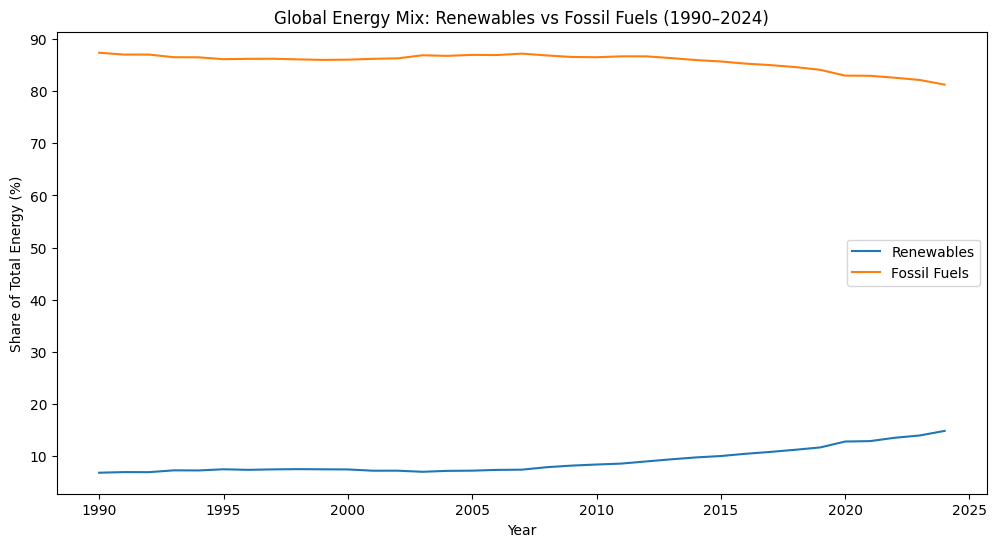

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    world['year'],
    world['renewables_share_energy'],
    label='Renewables'
)

plt.plot(
    world['year'],
    world['fossil_share_energy'],
    label='Fossil Fuels'
)

plt.title('Global Energy Mix: Renewables vs Fossil Fuels (1990–2024)')
plt.xlabel('Year')
plt.ylabel('Share of Total Energy (%)')

plt.legend()

plt.show()

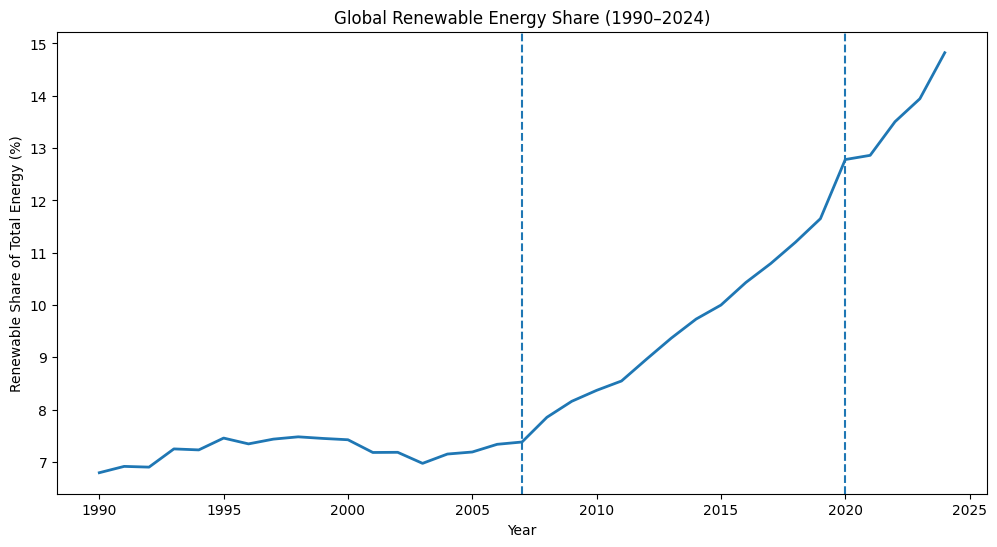

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
    world['year'],
    world['renewables_share_energy'],
    linewidth=2
)

# mögliche Wendepunkte markieren
plt.axvline(x=2007, linestyle='--')
plt.axvline(x=2020, linestyle='--')

plt.title('Global Renewable Energy Share (1990–2024)')
plt.xlabel('Year')
plt.ylabel('Renewable Share of Total Energy (%)')

plt.show()

## Question 1: How Has the Global Share of Renewable Energy Developed?

### Key Findings

- The global share of renewable energy increased from 6.8% in 1990 to 14.8% in 2024.
- Growth accelerated noticeably after 2008.
- A small slowdown can be observed around 2020, followed by continued growth.
- Despite the steady increase in renewable energy, fossil fuels continue to dominate the global energy mix.

In [26]:
df_2024 = df[df['year'] == 2024]

In [28]:
df_2024 = df[df['year'] == 2024]

df_2024[
    ['country', 'iso_code', 'renewables_share_energy']
].sort_values(
    'renewables_share_energy',
    ascending=False
).head(20)

,country,iso_code,renewables_share_energy
9573,Iceland,ISL,80.498
15169,Norway,NOR,71.812
20021,Sweden,SWE,51.318
3117,Brazil,BRA,49.616
16611,Other South America (EI),NaN,44.722
1897,Austria,AUT,43.347
13962,New Zealand,NZL,42.554
5804,Denmark,DNK,41.722
20147,Switzerland,CHE,39.868
17745,Portugal,PRT,39.741


In [36]:
countries_2024 = df_2024[
    df_2024['iso_code'].notna()
].copy()

countries_2024[
    ['country', 'renewables_share_energy']
].sort_values(
    'renewables_share_energy',
    ascending=False
).head(15)

,country,renewables_share_energy
9573,Iceland,80.498
15169,Norway,71.812
20021,Sweden,51.318
3117,Brazil,49.616
1897,Austria,43.347
13962,New Zealand,42.554
5804,Denmark,41.722
20147,Switzerland,39.868
17745,Portugal,39.741
7684,Finland,38.894


In [37]:
countries_2024[
    countries_2024['country'] == 'Germany'
][['country', 'renewables_share_energy']]

,country,renewables_share_energy
8281,Germany,23.968


In [38]:
countries_2024['renewables_share_energy'].median()

13.045

In [39]:
countries_2024[
    countries_2024['country'] == 'Germany'
].index

Index([8281], dtype='int64')

In [40]:
countries_2024[
    ['country', 'renewables_share_energy']
].sort_values(
    'renewables_share_energy',
    ascending=False
).head(10)

,country,renewables_share_energy
9573,Iceland,80.498
15169,Norway,71.812
20021,Sweden,51.318
3117,Brazil,49.616
1897,Austria,43.347
13962,New Zealand,42.554
5804,Denmark,41.722
20147,Switzerland,39.868
17745,Portugal,39.741
7684,Finland,38.894


In [41]:
top10 = countries_2024[
    ['country', 'renewables_share_energy']
].sort_values(
    'renewables_share_energy',
    ascending=False
).head(10)

germany = countries_2024[
    countries_2024['country'] == 'Germany'
][['country', 'renewables_share_energy']]

plot_df = pd.concat([top10, germany])

plot_df

,country,renewables_share_energy
9573,Iceland,80.498
15169,Norway,71.812
20021,Sweden,51.318
3117,Brazil,49.616
1897,Austria,43.347
13962,New Zealand,42.554
5804,Denmark,41.722
20147,Switzerland,39.868
17745,Portugal,39.741
7684,Finland,38.894


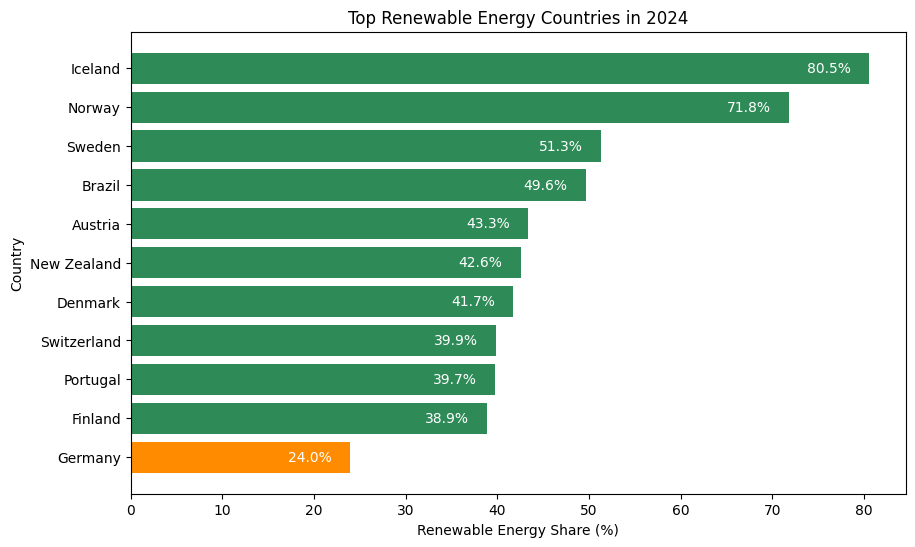

In [52]:
plot_df = plot_df.sort_values(
    'renewables_share_energy',
    ascending=True
)

plt.figure(figsize=(10,6))

colors = [
    'darkorange' if country == 'Germany' else 'seagreen'
    for country in plot_df['country']
]

plt.barh(
    plot_df['country'],
    plot_df['renewables_share_energy'],
    color=colors
)

plt.title('Top Renewable Energy Countries in 2024')
plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('Country')

for index, value in enumerate(plot_df['renewables_share_energy']):
    plt.text(
        value - 2,
        index,
        f'{value:.1f}%',
        va='center',
        ha='right',
        color='white'
    )

plt.show()

In [53]:
countries = df[df['iso_code'].notna()].copy()

countries_1990 = countries[
    countries['year'] == 1990
][['country', 'renewables_share_energy']]

countries_2024 = countries[
    countries['year'] == 2024
][['country', 'renewables_share_energy']]

In [55]:
countries_1990.shape

(209, 2)

In [56]:
countries_2024.shape

(199, 2)

In [57]:
comparison = countries_1990.merge(
    countries_2024,
    on='country',
    suffixes=('_1990', '_2024')
)

comparison.shape

(188, 3)

In [58]:
comparison['improvement'] = (
    comparison['renewables_share_energy_2024']
    - comparison['renewables_share_energy_1990']
)

comparison.head()

,country,renewables_share_energy_1990,renewables_share_energy_2024,improvement
0,Afghanistan,NaN,NaN,NaN
1,Albania,NaN,NaN,NaN
2,Algeria,0.119,0.242,0.123
3,American Samoa,NaN,NaN,NaN
4,Angola,NaN,NaN,NaN


In [59]:
comparison[
    ['country', 'improvement']
].sort_values(
    'improvement',
    ascending=False
).head(15)

,country,improvement
47,Denmark,40.518
137,Portugal,26.005
58,Finland,24.424
99,Lithuania,22.824
63,Germany,22.704
78,Iceland,21.415
179,United Kingdom,20.650
83,Ireland,20.536
66,Greece,19.341
159,Spain,19.044


In [60]:
comparison = comparison.dropna(
    subset=[
        'renewables_share_energy_1990',
        'renewables_share_energy_2024'
    ]
)

comparison.shape

(79, 4)

In [62]:
comparison.head()

,country,renewables_share_energy_1990,renewables_share_energy_2024,improvement
2,Algeria,0.119,0.242,0.123
6,Argentina,9.729,14.803,5.074
8,Australia,4.137,14.733,10.596
9,Austria,27.764,43.347,15.583
10,Azerbaijan,1.770,4.303,2.533


In [61]:
comparison[
    ['country', 'improvement']
].sort_values(
    'improvement',
    ascending=False
).head(15)

,country,improvement
47,Denmark,40.518
137,Portugal,26.005
58,Finland,24.424
99,Lithuania,22.824
63,Germany,22.704
78,Iceland,21.415
179,United Kingdom,20.650
83,Ireland,20.536
66,Greece,19.341
159,Spain,19.044


In [65]:
top10_improvement = comparison[
    ['country', 'improvement']
].sort_values(
    'improvement',
    ascending=False
).head(10)

top10_improvement

,country,improvement
47,Denmark,40.518
137,Portugal,26.005
58,Finland,24.424
99,Lithuania,22.824
63,Germany,22.704
78,Iceland,21.415
179,United Kingdom,20.650
83,Ireland,20.536
66,Greece,19.341
159,Spain,19.044


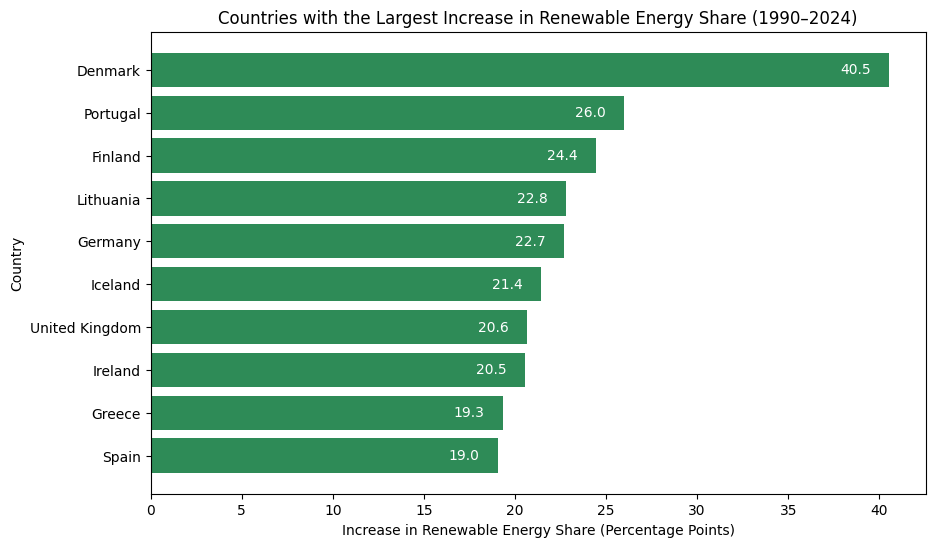

In [67]:
plot_df = top10_improvement.sort_values(
    'improvement',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    plot_df['country'],
    plot_df['improvement'],
    color='seagreen'
)

plt.title(
    'Countries with the Largest Increase in Renewable Energy Share (1990–2024)'
)

plt.xlabel('Increase in Renewable Energy Share (Percentage Points)')
plt.ylabel('Country')

for index, value in enumerate(plot_df['improvement']):
    plt.text(
        value - 1,
        index,
        f'{value:.1f}',
        va='center',
        ha='right',
        color='white'
    )

plt.show()

## Question 2: Which Countries Are Leading the Energy Transition?

### Part 1: Countries with the Highest Share of Renewable Energy (2024)

#### Key Findings

* Iceland leads the ranking with a renewable energy share of 80.5%.
* Other leading countries include Norway (71.8%) and Sweden (51.3%).
* Many of the top-ranked countries benefit from favorable geographic conditions, such as hydropower or geothermal energy resources.
* Germany reaches 24.0% and ranks 21st worldwide.
* Despite its relatively lower ranking, Germany remains well above the global median of 13.0%.

### Part 2: Countries with the Largest Improvement Since 1990

#### Key Findings

* The largest increases in renewable energy share were achieved primarily by European countries.
* Denmark recorded the strongest improvement worldwide, increasing its renewable energy share by 40.5 percentage points.
* Germany ranks fifth globally, with an increase of 22.7 percentage points.
* Countries with the highest renewable energy shares today are not necessarily the countries that achieved the largest improvements since 1990.
* While some countries benefited from favorable natural conditions early on, others achieved substantial progress through targeted renewable energy investments and long-term energy policies.


In [71]:
countries_2024 = df[
    (df['year'] == 2024)
    & (df['iso_code'].notna())
].copy()

In [75]:
countries_2024[
    ['country', 'fossil_share_energy']
].sort_values(
    'fossil_share_energy',
    ascending=False
).head(20)

,country,fossil_share_energy
21191,Turkmenistan,99.993
20899,Trinidad and Tobago,99.989
10952,Kuwait,99.924
772,Algeria,99.758
18886,Singapore,99.455
10075,Iraq,99.416
18641,Saudi Arabia,99.272
17917,Qatar,99.189
9387,Hong Kong,98.952
2234,Bangladesh,98.905


In [76]:
countries_2024[
    countries_2024['country'] == 'Germany'
][['country', 'fossil_share_energy']]

,country,fossil_share_energy
8281,Germany,76.032


In [77]:
countries_2024['fossil_share_energy'].median()

80.93

In [85]:
countries_2024[
    ['country', 'fossil_share_energy']
].sort_values(
    'fossil_share_energy',
    ascending=False
).reset_index(drop=True)

,country,fossil_share_energy
0,Turkmenistan,99.993
1,Trinidad and Tobago,99.989
2,Kuwait,99.924
3,Algeria,99.758
4,Singapore,99.455
...,...,...
194,Uganda,NaN
195,Uruguay,NaN
196,Yemen,NaN
197,Zambia,NaN


In [80]:
ranking = countries_2024[
    ['country', 'fossil_share_energy']
].sort_values(
    'fossil_share_energy',
    ascending=False
).reset_index(drop=True)

ranking[
    ranking['country'] == 'Germany'
]

,country,fossil_share_energy
50,Germany,76.032


In [87]:
top10_fossil = countries_2024[
    ['country', 'fossil_share_energy']
].sort_values(
    'fossil_share_energy',
    ascending=False
).head(10)

top10_fossil

,country,fossil_share_energy
21191,Turkmenistan,99.993
20899,Trinidad and Tobago,99.989
10952,Kuwait,99.924
772,Algeria,99.758
18886,Singapore,99.455
10075,Iraq,99.416
18641,Saudi Arabia,99.272
17917,Qatar,99.189
9387,Hong Kong,98.952
2234,Bangladesh,98.905


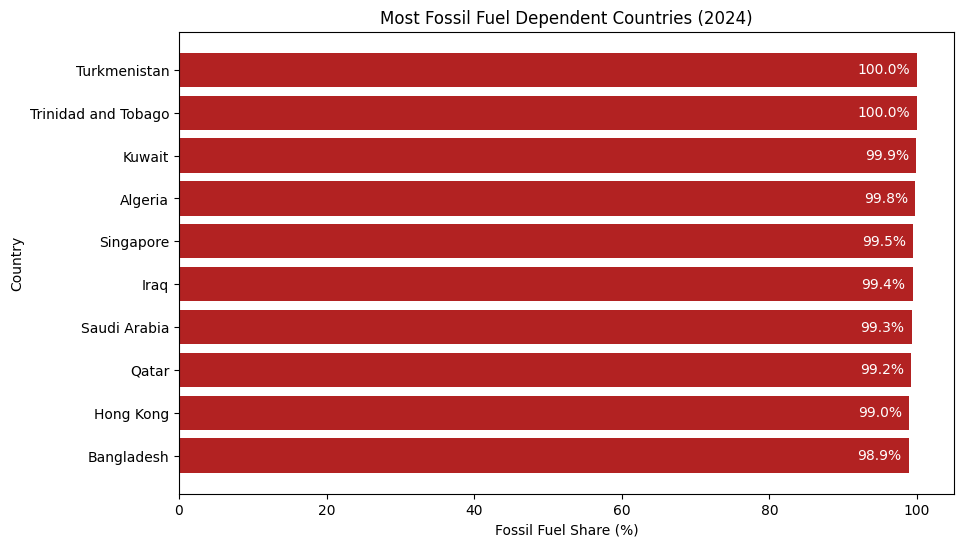

In [89]:
plot_df = top10_fossil.sort_values(
    'fossil_share_energy',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    plot_df['country'],
    plot_df['fossil_share_energy'],
    color='firebrick'
)

plt.title(
    'Most Fossil Fuel Dependent Countries (2024)'
)

plt.xlabel('Fossil Fuel Share (%)')
plt.ylabel('Country')

for index, value in enumerate(plot_df['fossil_share_energy']):
    plt.text(
        value - 1,
        index,
        f'{value:.1f}%',
        va='center',
        ha='right',
        color='white'
    )

plt.show()

In [91]:
import country_converter as coco

In [92]:
countries_2024['continent'] = coco.convert(
    names=countries_2024['country'],
    to='continent'
)

Netherlands Antilles not found in regex


In [93]:
countries_2024[
    ['country', 'continent']
].sample(10)

,country,continent
6588,Equatorial Guinea,Africa
13837,New Caledonia,Oceania
942,Angola,Africa
13025,Montserrat,America
5804,Denmark,Europe
13436,Namibia,Africa
20432,Tajikistan,Asia
3458,Burkina Faso,Africa
3939,Canada,America
18947,Slovakia,Europe


In [94]:
countries_2024['continent'].value_counts()

continent
Asia         51
Africa       51
America      42
Europe       40
Oceania      14
not found     1
Name: count, dtype: int64

In [96]:
europe_2024 = countries_2024[
    countries_2024['continent'] == 'Europe'
].copy()

europe_2024.shape

(40, 131)

In [97]:
europe_2024[
    ['country', 'fossil_share_energy']
].sort_values(
    'fossil_share_energy',
    ascending=False
).head(15)

,country,fossil_share_energy
18158,Russia,88.159
17619,Poland,86.955
2400,Belarus,86.791
11710,Luxembourg,85.722
14999,North Macedonia,83.963
6659,Estonia,82.054
13731,Netherlands,80.930
10452,Italy,79.069
8577,Greece,78.945
10200,Ireland,77.820


In [98]:
countries_2024[
    countries_2024['country'].isin(
        ['Netherlands', 'Germany']
    )
][[
    'country',
    'renewables_share_energy',
    'gas_share_energy',
    'oil_share_energy',
    'coal_share_energy',
    'fossil_share_energy'
]]

,country,renewables_share_energy,gas_share_energy,oil_share_energy,coal_share_energy,fossil_share_energy
8281,Germany,23.968,24.886,37.265,13.880,76.032
13731,Netherlands,18.119,28.492,47.188,5.249,80.930


In [99]:
top10_europe_fossil = europe_2024[
    ['country', 'fossil_share_energy']
].sort_values(
    'fossil_share_energy',
    ascending=False
).head(10)

top10_europe_fossil

,country,fossil_share_energy
18158,Russia,88.159
17619,Poland,86.955
2400,Belarus,86.791
11710,Luxembourg,85.722
14999,North Macedonia,83.963
6659,Estonia,82.054
13731,Netherlands,80.930
10452,Italy,79.069
8577,Greece,78.945
10200,Ireland,77.820


In [100]:
plot_df = top10_europe_fossil.sort_values(
    'fossil_share_energy',
    ascending=True
)

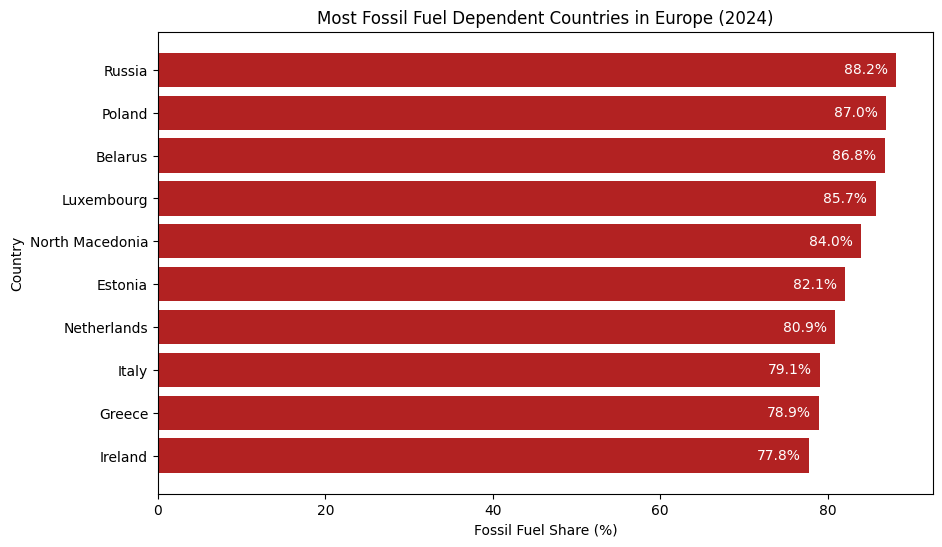

In [102]:
plt.figure(figsize=(10,6))

plt.barh(
    plot_df['country'],
    plot_df['fossil_share_energy'],
    color='firebrick'
)

plt.title(
    'Most Fossil Fuel Dependent Countries in Europe (2024)'
)

plt.xlabel('Fossil Fuel Share (%)')
plt.ylabel('Country')

for index, value in enumerate(plot_df['fossil_share_energy']):
    plt.text(
        value - 1,
        index,
        f'{value:.1f}%',
        va='center',
        ha='right',
        color='white'
    )

plt.show()

## Question 3: Which Countries Remain Highly Dependent on Fossil Fuels?

### Global Perspective

#### Key Findings

* The highest levels of fossil fuel dependence are primarily found in oil- and gas-rich countries.
* Several countries still obtain almost all of their energy from fossil fuels in 2024.
* Turkmenistan, Trinidad and Tobago, and Kuwait reach fossil fuel shares close to 100%.

### European Perspective

#### Key Findings

* Russia has the highest fossil fuel dependence in Europe, with a fossil fuel share of 88.2%.
* Poland and Belarus follow closely, both exceeding 86%.
* Germany's fossil fuel share remains high at 76.0%. Although Germany is not among the ten most fossil-dependent countries in Europe, it continues to rely heavily on fossil energy sources.
* The results demonstrate that the energy transition is progressing at very different speeds across European countries.


In [103]:
[col for col in df.columns if 'emission' in col.lower()]

['greenhouse_gas_emissions']

In [104]:
countries_2024[
    ['country', 'greenhouse_gas_emissions']
].sort_values(
    'greenhouse_gas_emissions',
    ascending=False
).head(15)

,country,greenhouse_gas_emissions
4606,China,5602.24
21997,United States,1685.19
9698,India,1436.57
18158,Russia,539.33
10623,Japan,491.35
18641,Saudi Arabia,314.59
19450,South Korea,259.85
9949,Iran,256.74
9824,Indonesia,252.74
20398,Taiwan,183.29


In [105]:
countries_2024[
    ['country', 'greenhouse_gas_emissions']
].sort_values(
    'greenhouse_gas_emissions',
    ascending=False
).tail(15)

,country,greenhouse_gas_emissions
13436,Namibia,0.08
2572,Belize,0.08
19029,Solomon Islands,0.07
18472,Samoa,0.06
9052,Guinea-Bissau,0.05
20774,Tonga,0.04
13481,Nauru,0.03
10801,Kiribati,0.02
13025,Montserrat,0.01
18826,Sierra Leone,0.01


In [106]:
countries_2024[['country', 'population']].head()

,country,population
150,Afghanistan,42647502.0
647,Albania,2791756.0
772,Algeria,46814302.0
817,American Samoa,46792.0
942,Angola,37885854.0


In [109]:
countries_2024['ghg_per_capita'] = (
    countries_2024['greenhouse_gas_emissions']
    / countries_2024['population']
) * 1_000_000

In [110]:
countries_2024[
    ['country', 'ghg_per_capita']
].sort_values(
    'ghg_per_capita',
    ascending=False
).head(10)

,country,ghg_per_capita
2109,Bahrain,21.306001
10952,Kuwait,11.905949
17917,Qatar,10.815407
3287,Brunei,10.718901
18641,Saudi Arabia,9.262795
20398,Taiwan,7.895679
21746,United Arab Emirates,7.515098
8837,Guam,6.734609
4030,Cayman Islands,6.042215
2662,Bermuda,6.031550


In [111]:
countries_2024[
    ['country',
     'renewables_share_energy',
     'ghg_per_capita']
].describe()

,renewables_share_energy,ghg_per_capita
count,79.000000,196.000000
mean,17.405430,1.668924
std,15.898968,2.541569
min,0.007000,0.000000
25%,5.888500,0.203881
50%,13.045000,0.751302
75%,24.352000,2.087729
max,80.498000,21.306001


In [112]:
scatter_df = countries_2024[
    [
        'country',
        'renewables_share_energy',
        'ghg_per_capita'
    ]
].dropna()

scatter_df.shape

(78, 3)

In [113]:
scatter_df[
    [
        'renewables_share_energy',
        'ghg_per_capita'
    ]
].corr()

,renewables_share_energy,ghg_per_capita
renewables_share_energy,1.000000,-0.467456
ghg_per_capita,-0.467456,1.000000


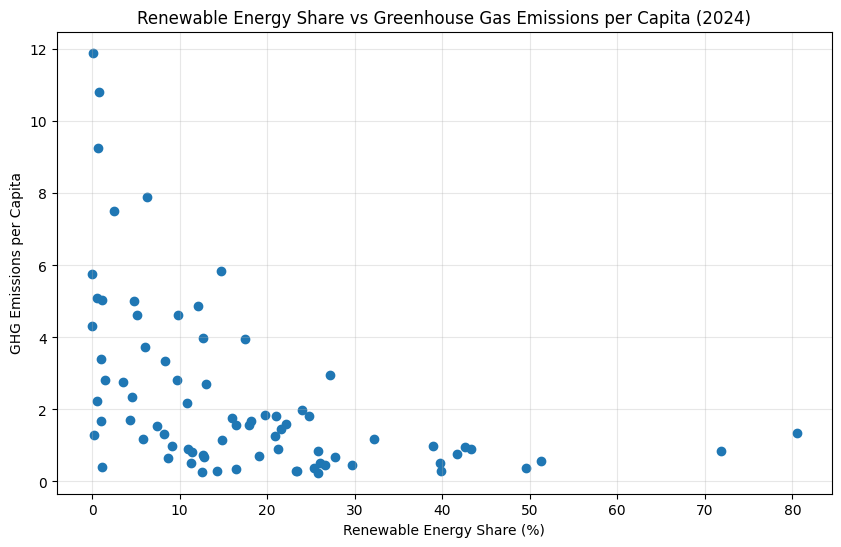

In [114]:
plt.figure(figsize=(10,6))

plt.scatter(
    scatter_df['renewables_share_energy'],
    scatter_df['ghg_per_capita']
)

plt.title(
    'Renewable Energy Share vs Greenhouse Gas Emissions per Capita (2024)'
)

plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('GHG Emissions per Capita')

plt.grid(alpha=0.3)

plt.show()

In [117]:
scatter_df.sort_values(
    'ghg_per_capita',
    ascending=False
)[[
    'country',
    'renewables_share_energy',
    'ghg_per_capita'
]].head(15)

,country,renewables_share_energy,ghg_per_capita
10952,Kuwait,0.076,11.905949
17917,Qatar,0.811,10.815407
18641,Saudi Arabia,0.728,9.262795
20398,Taiwan,6.268,7.895679
21746,United Arab Emirates,2.519,7.515098
1727,Australia,14.733,5.839060
21191,Turkmenistan,0.007,5.753557
18886,Singapore,0.545,5.097398
15914,Oman,1.115,5.045875
19450,South Korea,4.748,5.024403


In [118]:
scatter_df[
    scatter_df['renewables_share_energy'] > 40
][[
    'country',
    'renewables_share_energy',
    'ghg_per_capita'
]].sort_values(
    'renewables_share_energy',
    ascending=False
)

,country,renewables_share_energy,ghg_per_capita
9573,Iceland,80.498,1.347216
15169,Norway,71.812,0.835626
20021,Sweden,51.318,0.566607
3117,Brazil,49.616,0.373069
1897,Austria,43.347,0.890271
13962,New Zealand,42.554,0.945542
5804,Denmark,41.722,0.772909


In [120]:
europe_2024 = countries_2024[
    countries_2024['continent'] == 'Europe'
].copy()

In [121]:
europe_scatter = europe_2024[
    [
        'country',
        'renewables_share_energy',
        'ghg_per_capita'
    ]
].dropna()

In [122]:
europe_scatter.shape

(32, 3)

In [123]:
europe_scatter[
    [
        'renewables_share_energy',
        'ghg_per_capita'
    ]
].corr()

,renewables_share_energy,ghg_per_capita
renewables_share_energy,1.000000,-0.335798
ghg_per_capita,-0.335798,1.000000


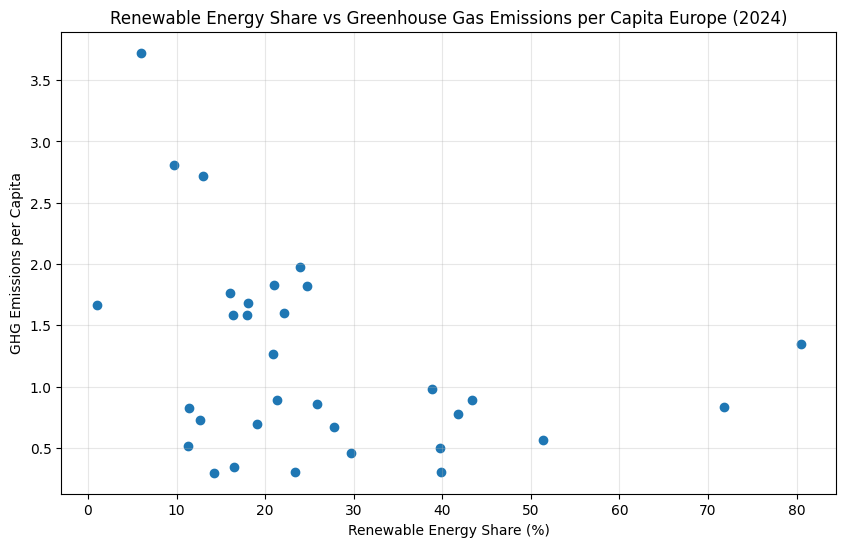

In [124]:
plt.figure(figsize=(10,6))

plt.scatter(
    europe_scatter['renewables_share_energy'],
    europe_scatter['ghg_per_capita']
)

plt.title(
    'Renewable Energy Share vs Greenhouse Gas Emissions per Capita Europe (2024)'
)

plt.xlabel('Renewable Energy Share (%)')
plt.ylabel('GHG Emissions per Capita')

plt.grid(alpha=0.3)

plt.show()

## Question 4: Is There a Relationship Between Renewable Energy Share and Greenhouse Gas Emissions?

### Key Findings

* The analysis reveals a moderate negative relationship between renewable energy share and greenhouse gas emissions per capita (correlation coefficient: -0.467).
* Countries with lower renewable energy shares often exhibit significantly higher greenhouse gas emissions per capita.
* Fossil fuel-dependent countries such as Kuwait, Qatar, and Saudi Arabia combine very low renewable energy shares with exceptionally high emission levels.
* Countries with high renewable energy shares, including Iceland, Norway, Sweden, and Denmark, show considerably lower greenhouse gas emissions per capita.
* The relationship is not perfect. The dispersion of the data suggests that factors beyond the energy mix, such as industry, transportation, economic activity, and overall energy consumption, also influence national emission levels.

# Conclusion

The global energy transition has made measurable progress over the last three decades. The share of renewable energy in the global energy mix increased steadily from 1990 to 2024, with growth accelerating after 2008.

Several countries, particularly Iceland, Norway and Sweden, have already achieved very high shares of renewable energy. Other countries, including Germany and Denmark, stand out due to their significant improvements over time.

Despite this progress, fossil fuels continue to dominate global energy consumption. Many oil- and gas-producing countries remain highly dependent on fossil energy sources, with fossil fuel shares exceeding 90%.

The analysis also identified a moderate negative relationship between renewable energy adoption and greenhouse gas emissions per capita. Countries with higher renewable energy shares generally tend to have lower emissions. However, the European analysis showed that renewable energy alone does not fully explain emission levels, indicating that additional factors such as industrial structure, transportation and energy efficiency also play important roles.

Overall, the findings suggest that renewable energy expansion contributes to a more sustainable energy system, but the transition away from fossil fuels remains incomplete.
